In [1]:
# ============================================================
# CELL 1: Import Required Libraries
# ============================================================
# Core data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Machine Learning library
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Tree-based models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("✅ All libraries imported successfully!")
print("\n📦 Key packages we'll use:")
print("   • DecisionTreeClassifier - Single decision tree model")
print("   • RandomForestClassifier - Ensemble of decision trees")
print("   • plot_tree - Visualize decision tree structure")
print("   • GridSearchCV - Hyperparameter tuning")

✅ All libraries imported successfully!

📦 Key packages we'll use:
   • DecisionTreeClassifier - Single decision tree model
   • RandomForestClassifier - Ensemble of decision trees
   • plot_tree - Visualize decision tree structure
   • GridSearchCV - Hyperparameter tuning


In [2]:
# ============================================================
# CELL 2: Load the Life Expectancy Dataset
# ============================================================
data_string = """Country,Sum of Females  Life Expectancy,Sum of Life Expectancy  (both sexes),Sum of Males  Life Expectancy
Chad,57.19,55.24,53.36
Nigeria,54.94,54.64,54.33
South Sudan,60.75,57.74,54.76
Lesotho,60.44,57.8,55.03
Central African Republic,59.56,57.67,55.51
Somalia,61.55,58.97,56.49
Burkina Faso,63.43,61.29,59.11
Mali,62.15,60.68,59.25
Benin,62.42,60.96,59.52
Guinea,62.09,60.9,59.66
DR Congo,64.23,62.07,59.96
Côte d'Ivoire,64.31,62.11,60.17
Sierra Leone,63.7,61.96,60.23
Mozambique,66.74,63.8,60.49
Niger,62.41,61.43,60.49
Zimbabwe,65.31,63.06,60.49
Liberia,63.63,62.32,61.02
Eswatini,67.11,64.26,61.32
Kenya,66.12,63.83,61.64
Burundi,65.88,63.82,61.75
Cameroon,66.23,63.97,61.78
Guinea-Bissau,66.55,64.25,61.82
Haiti,68.49,65.12,61.9
Madagascar,65.6,63.84,62.12
Equatorial Guinea,65.89,63.91,62.22
Angola,67.34,64.81,62.28
Togo,63.15,62.93,62.7
South Africa,69.79,66.31,62.78
Ghana,68.16,65.7,63.31
Namibia,71.48,67.52,63.45
Sudan,69.83,66.52,63.45
Djibouti,68.74,66.2,63.73
Papua New Guinea,69.21,66.26,63.84
Myanmar,70.38,67.1,63.99
Zambia,68.87,66.53,64.1
Malawi,70.77,67.56,64.27
Congo,67.72,66,64.33
Gambia,67.75,66.06,64.35
Ethiopia,71.02,67.6,64.36
Tanzania,70,67.21,64.4
Kiribati,68.32,66.6,64.69
Afghanistan,67.81,66.29,64.7
Comoros,69.2,67.02,65.02
State of Palestine,74.25,69.21,65.22
Pakistan,70.32,67.8,65.46
Fiji,69.54,67.46,65.47
Uganda,71.37,68.49,65.49
Rwanda,70.14,68.02,65.71
Gabon,71.24,68.51,66.06
Bolivia,71.32,68.74,66.27
Timor-Leste,69.67,67.9,66.27
Sao Tome & Principe,73.91,69.91,66.41
Guyana,74.09,70.32,66.62
Mauritania,70.73,68.71,66.7
Moldova,75.67,71.33,66.7
Eritrea,70.94,68.89,66.76
Botswana,71.85,69.29,66.78
Philippines,72.96,69.95,66.99
Turkmenistan,73.01,70.2,67
Senegal,71.01,68.92,67.01
Laos,71.53,69.23,67.02
Yemen,71.55,69.44,67.37
Russia,79.19,73.34,67.48
Mongolia,76.66,71.99,67.49
El Salvador,76.49,72.3,67.76
Cambodia,73.36,70.82,68.15
Kyrgyzstan,75.4,71.82,68.31
St. Vincent & Grenadines,74.48,71.38,68.78
Venezuela,76.66,72.67,68.89
Jamaica,74.15,71.61,69.08
Nepal,72.14,70.64,69.09
Indonesia,73.43,71.29,69.16
Solomon Islands,72.18,70.69,69.36
Saint Lucia,76.45,72.85,69.45
Tonga,76.54,73.07,69.5
Uzbekistan,75.55,72.53,69.56
Vanuatu,74.11,71.65,69.59
Libya,72.68,71.12,69.63
Egypt,74.01,71.81,69.65
Tajikistan,74.14,71.93,69.68
Belarus,79.22,74.62,69.74
Georgia,79.23,74.66,69.75
Ukraine,79.39,74.69,69.79
Western Sahara,73.77,71.58,69.87
Samoa,73.82,71.83,69.96
Vietnam,79.38,74.74,70.05
Seychelles,76.66,72.99,70.08
Syria,74.92,72.56,70.21
Kazakhstan,78.52,74.53,70.27
Guatemala,75.04,72.75,70.44
Honduras,75.67,73.04,70.49
Iraq,74.18,72.42,70.5
Trinidad and Tobago,76.83,73.62,70.51
Suriname,76.98,73.76,70.6
Dominican Republic,77.11,73.87,70.66
India,73.86,72.24,70.73
U.S. Virgin Islands,81.48,75.7,70.73
Paraguay,77.09,73.98,71.01
Bahamas,78.33,74.71,71.06
Belize,76.66,73.74,71.08
Lithuania,80.8,76.17,71.42
North Korea,75.88,73.74,71.55
Bhutan,75.27,73.26,71.57
Armenia,79.6,75.85,71.58
Azerbaijan,77.29,74.58,71.71
Latvia,80.6,76.33,71.75
Mauritius,78.34,75.1,72.11
Bulgaria,79.36,75.8,72.33
Thailand,80.98,76.56,72.34
Mexico,78,75.26,72.44
Nicaragua,77.58,75.1,72.46
Grenada,78.5,75.37,72.52
Romania,79.68,76.09,72.56
Curaçao,80.96,76.99,72.66
Brazil,79.15,76.02,72.95
Cabo Verde,79.37,76.22,73.05
Bangladesh,76.67,74.93,73.3
Morocco,77.78,75.49,73.35
Brunei,77.73,75.5,73.49
Guam,81.59,77.42,73.66
Serbia,80.18,76.94,73.68
Barbados,78.76,76.33,73.75
Aruba,78.92,76.5,73.85
Hungary,80.33,77.18,73.89
Montenegro,80.45,77.25,73.92
Tunisia,79.33,76.71,74.13
Mayotte,78.51,76.24,74.27
French Guiana,80.15,77.18,74.33
Uruguay,82.04,78.29,74.38
Malaysia,79.52,76.82,74.45
Sri Lanka,80.75,77.67,74.45
Turkey,80.34,77.42,74.62
Bosnia and Herzegovina,81.07,78.04,74.65
Antigua and Barbuda,80.45,77.77,74.74
Ecuador,80.31,77.58,74.88
Argentina,80.02,77.54,74.98
Algeria,77.91,76.48,75.1
Poland,82.49,78.81,75.1
Estonia,83.17,79.31,75.12
Colombia,80.61,77.91,75.16
Slovakia,81.71,78.49,75.21
China,80.97,78.02,75.25
North Macedonia,79.71,77.54,75.26
Croatia,81.82,78.75,75.6
Peru,80.3,77.94,75.63
Cuba,80.68,78.26,75.86
Lebanon,79.86,77.95,75.88
Jordan,80.34,77.98,75.89
Iran,79.81,77.85,76
New Caledonia,81.41,78.92,76.46
Panama,82.71,79.78,76.88
United States,81.98,79.46,77.05
Czech Republic (Czechia),82.75,79.97,77.18
Saudi Arabia,81.33,78.98,77.33
Taiwan,83.75,80.75,77.86
Albania,81.59,79.78,77.92
Puerto Rico,85.38,81.9,78.28
Guadeloupe,85.65,82.24,78.35
Costa Rica,83.58,81,78.37
Oman,82.05,80.25,78.72
Slovenia,84.47,81.78,79.11
Germany,83.88,81.54,79.21
Finland,84.79,82.08,79.38
Chile,83.23,81.36,79.45
Kuwait,82,80.6,79.45
Martinique,85.73,82.74,79.45
Greece,84.46,82.03,79.5
United Kingdom,83.33,81.45,79.54
Portugal,85.25,82.55,79.68
Austria,84.45,82.12,79.75
Cyprus,83.8,81.82,79.84
Maldives,83,81.29,79.95
Belgium,84.45,82.27,80.06
Denmark,83.98,82.09,80.21
Canada,84.91,82.72,80.53
Ireland,84.61,82.58,80.58
France,86.2,83.46,80.59
New Zealand,83.89,82.25,80.6
Israel,84.71,82.73,80.67
Réunion,86.45,83.67,80.67
Netherlands,83.85,82.3,80.72
Luxembourg,83.94,82.36,80.75
Bahrain,82.13,81.42,80.86
Macao,85.35,83.23,81.05
Spain,86.44,83.8,81.1
South Korea,87.28,84.43,81.32
Singapore,86.36,83.86,81.38
Malta,85.39,83.47,81.48
Iceland,84.47,83.01,81.63
Sweden,85.22,83.42,81.65
Italy,85.87,83.87,81.75
Qatar,83.48,82.52,81.78
Japan,87.88,84.85,81.83
French Polynesia,86.62,84.19,81.9
Norway,84.97,83.46,81.94
Switzerland,85.95,84.09,82.17
United Arab Emirates,84.32,83.07,82.17
Australia,85.85,84.07,82.28
Hong Kong,88.26,85.63,82.97"""

from io import StringIO
df = pd.read_csv(StringIO(data_string))
df.columns = ['Country', 'Female_LE', 'Both_LE', 'Male_LE']

print("🌍 LIFE EXPECTANCY DATASET LOADED")
print("=" * 50)
print(f"\n📊 Dataset Shape: {df.shape[0]} countries × {df.shape[1]} columns")
print(f"\n📋 Features:")
print(f"   1. Female_LE - Female life expectancy (years)")
print(f"   2. Male_LE - Male life expectancy (years)")
print(f"\n🎯 Target: Both_LE - Both sexes life expectancy (years)")
print("\n" + "=" * 50)
print("\n🔍 First 5 rows of the dataset:")
df.head()

🌍 LIFE EXPECTANCY DATASET LOADED

📊 Dataset Shape: 199 countries × 4 columns

📋 Features:
   1. Female_LE - Female life expectancy (years)
   2. Male_LE - Male life expectancy (years)

🎯 Target: Both_LE - Both sexes life expectancy (years)


🔍 First 5 rows of the dataset:


,Country,Female_LE,Both_LE,Male_LE
0,Chad,57.19,55.24,53.36
1,Nigeria,54.94,54.64,54.33
2,South Sudan,60.75,57.74,54.76
3,Lesotho,60.44,57.80,55.03
4,Central African Republic,59.56,57.67,55.51


📊 Life Expectancy Thresholds:
   Low LE: < 71.3 years
   Medium LE: 71.3 - 77.6 years
   High LE: > 77.6 years


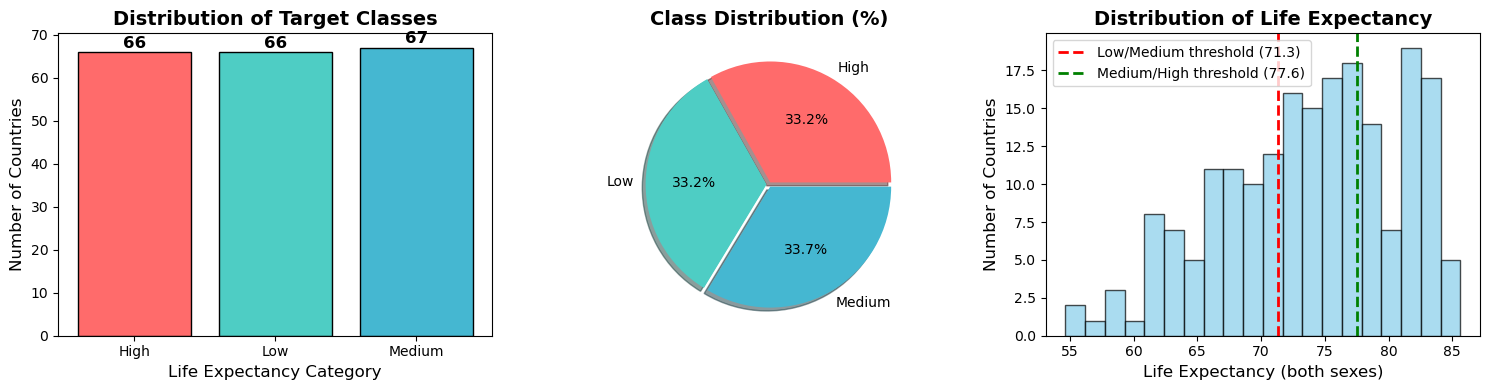


📊 Class Distribution Summary:
target_class
High      66
Low       66
Medium    67

✅ Dataset is balanced - good for classification!


In [3]:
# ============================================================
# CELL 3: Create Target Classes and Explore Distribution
# ============================================================
low_thresh = df['Both_LE'].quantile(0.33)
high_thresh = df['Both_LE'].quantile(0.67)

print(f"📊 Life Expectancy Thresholds:")
print(f"   Low LE: < {low_thresh:.1f} years")
print(f"   Medium LE: {low_thresh:.1f} - {high_thresh:.1f} years")
print(f"   High LE: > {high_thresh:.1f} years")

def categorize_le(le):
    if le < low_thresh:
        return 0  # Low
    elif le < high_thresh:
        return 1  # Medium
    else:
        return 2  # High

df['target'] = df['Both_LE'].apply(categorize_le)
df['target_class'] = df['target'].map({0: 'Low', 1: 'Medium', 2: 'High'})
class_counts = df['target_class'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Life Expectancy Category', fontsize=12)
axes[0].set_ylabel('Number of Countries', fontsize=12)
axes[0].set_title('Distribution of Target Classes', fontsize=14, fontweight='bold')

for i, (idx, val) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, val + 1, str(val), ha='center', fontsize=12, fontweight='bold')

axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, explode=[0.02, 0.02, 0.02], shadow=True)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

axes[2].hist(df['Both_LE'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[2].axvline(x=low_thresh, color='red', linestyle='--', linewidth=2, label=f'Low/Medium threshold ({low_thresh:.1f})')
axes[2].axvline(x=high_thresh, color='green', linestyle='--', linewidth=2, label=f'Medium/High threshold ({high_thresh:.1f})')
axes[2].set_xlabel('Life Expectancy (both sexes)', fontsize=12)
axes[2].set_ylabel('Number of Countries', fontsize=12)
axes[2].set_title('Distribution of Life Expectancy', fontsize=14, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n📊 Class Distribution Summary:")
print(class_counts.to_string())
print(f"\n✅ Dataset is balanced - good for classification!")

In [4]:
# ============================================================
# CELL 4: Prepare Data for Modeling
# ============================================================
feature_names = ['Female_LE', 'Male_LE']
X = df[feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("📊 DATA SPLIT COMPLETE")
print("=" * 50)
print(f"\n🔹 Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"🔹 Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n🔹 Number of features: {X_train.shape[1]}")

print("\n📈 Class distribution in splits:")
print(f"   Training: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"   Testing:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

📊 DATA SPLIT COMPLETE

🔹 Training set: 159 samples (80%)
🔹 Testing set:  40 samples (20%)

🔹 Number of features: 2

📈 Class distribution in splits:
   Training: {np.int64(0): np.int64(53), np.int64(1): np.int64(53), np.int64(2): np.int64(53)}
   Testing:  {np.int64(0): np.int64(13), np.int64(1): np.int64(14), np.int64(2): np.int64(13)}


In [5]:
# ============================================================
# CELL 5: Train a Basic Decision Tree
# ============================================================
dt_basic = DecisionTreeClassifier(
    random_state=42,
    criterion='gini'
)

dt_basic.fit(X_train, y_train)

y_train_pred = dt_basic.predict(X_train)
y_test_pred = dt_basic.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("🌳 BASIC DECISION TREE TRAINED")
print("=" * 50)
print(f"\n📊 Tree Properties:")
print(f"   • Depth: {dt_basic.get_depth()}")
print(f"   • Number of leaves: {dt_basic.get_n_leaves()}")
print(f"   • Number of features: {dt_basic.n_features_in_}")

print(f"\n🎯 Accuracy Results:")
print(f"   • Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   • Testing Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")

if train_acc == 1.0 and test_acc < 0.95:
    print("\n⚠️  Warning: 100% training accuracy with lower test accuracy")
    print("   This suggests OVERFITTING - the tree memorized the training data!")

🌳 BASIC DECISION TREE TRAINED

📊 Tree Properties:
   • Depth: 5
   • Number of leaves: 7
   • Number of features: 2

🎯 Accuracy Results:
   • Training Accuracy: 1.0000 (100.00%)
   • Testing Accuracy:  0.9250 (92.50%)

⚠️  Warning: 100% training accuracy with lower test accuracy
   This suggests OVERFITTING - the tree memorized the training data!


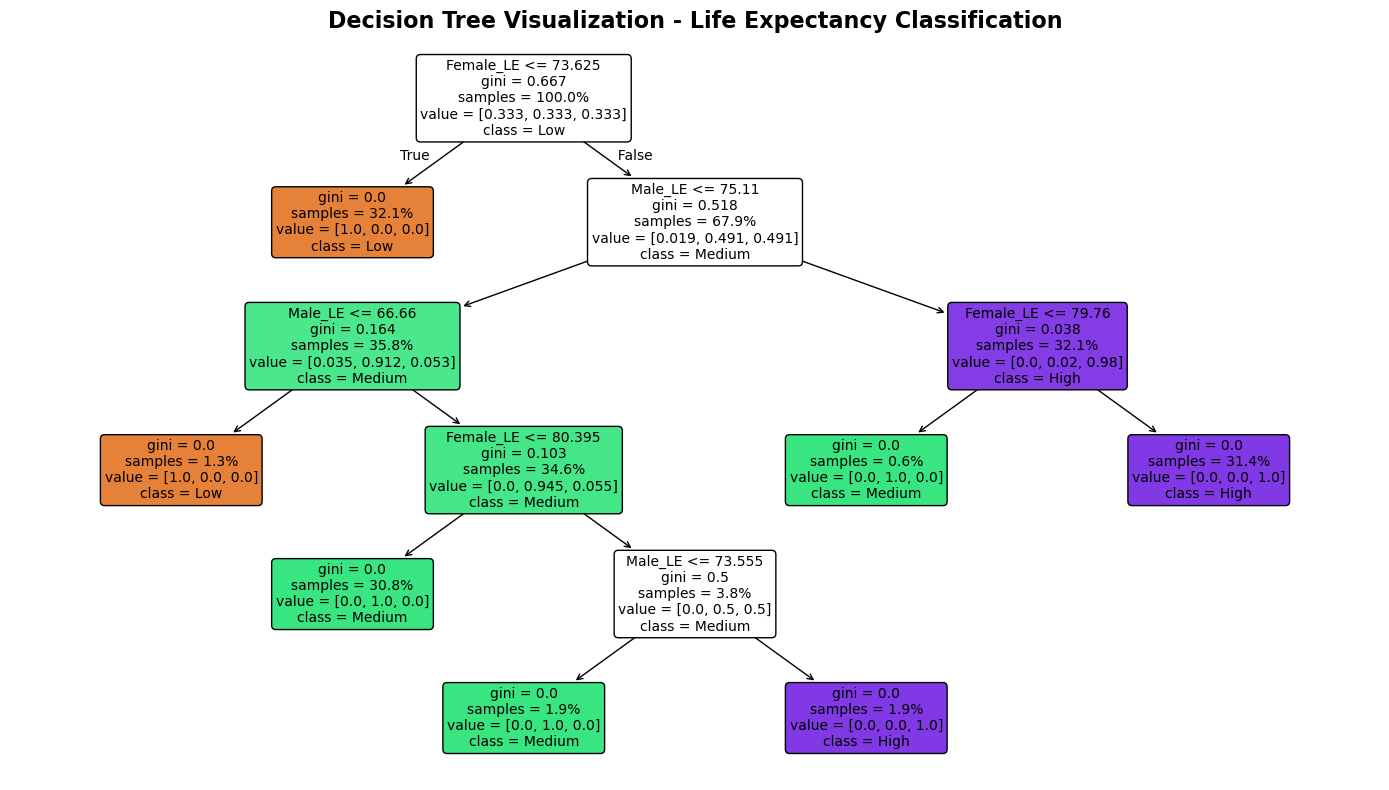


📖 How to Read the Tree:
   • Each box shows: feature ≤ threshold
   • 'gini': Impurity measure (0 = pure node)
   • 'samples': Percentage of training samples at this node
   • 'value': Distribution of classes [Low, Medium, High]
   • 'class': Predicted class if this were a leaf node
   • Colors: Darker = more pure (confident prediction)


In [6]:
# ============================================================
# CELL 6: Visualize the Decision Tree
# ============================================================
plt.figure(figsize=(14, 8))

plot_tree(
    dt_basic,
    feature_names=feature_names,
    class_names=['Low', 'Medium', 'High'],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True
)

plt.title('Decision Tree Visualization - Life Expectancy Classification', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📖 How to Read the Tree:")
print("   • Each box shows: feature ≤ threshold")
print("   • 'gini': Impurity measure (0 = pure node)")
print("   • 'samples': Percentage of training samples at this node")
print("   • 'value': Distribution of classes [Low, Medium, High]")
print("   • 'class': Predicted class if this were a leaf node")
print("   • Colors: Darker = more pure (confident prediction)")

🌳 SIMPLE DECISION TREE (max_depth=3)

📊 Tree Properties:
   • Depth: 3
   • Number of leaves: 5

🎯 Accuracy Comparison:
                    Full Tree    Simple Tree
   Training:        100.00%        98.11%
   Testing:          92.50%        92.50%


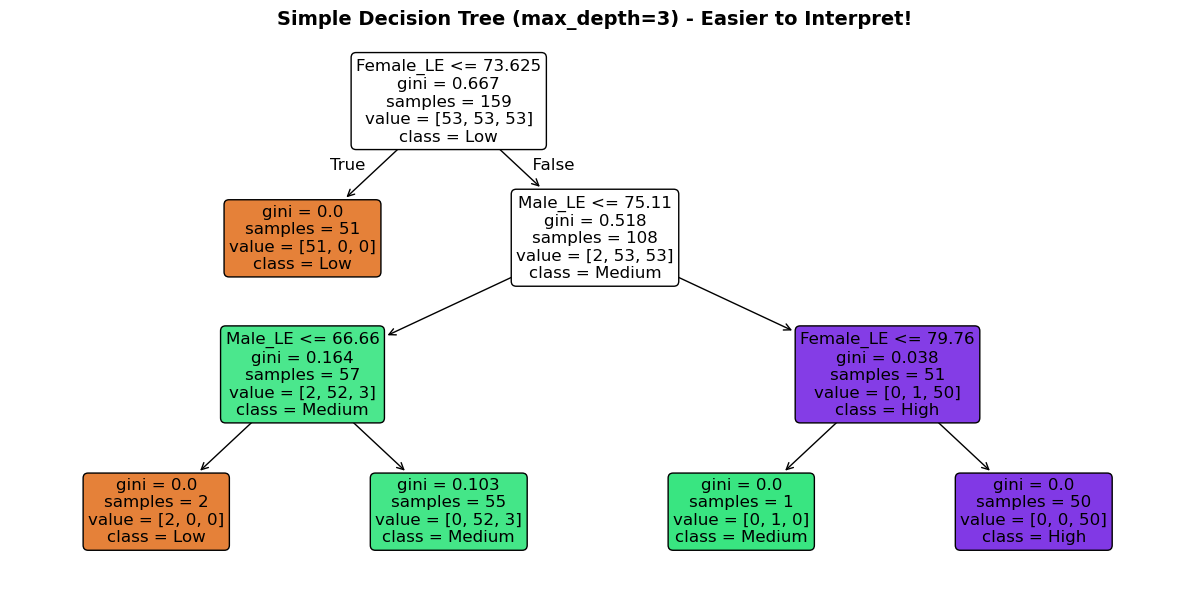

In [7]:
# ============================================================
# CELL 7: Create a Simpler Tree (Limit Depth)
# ============================================================
dt_simple = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    criterion='gini'
)

dt_simple.fit(X_train, y_train)

y_train_pred_simple = dt_simple.predict(X_train)
y_test_pred_simple = dt_simple.predict(X_test)

train_acc_simple = accuracy_score(y_train, y_train_pred_simple)
test_acc_simple = accuracy_score(y_test, y_test_pred_simple)

print("🌳 SIMPLE DECISION TREE (max_depth=3)")
print("=" * 50)
print(f"\n📊 Tree Properties:")
print(f"   • Depth: {dt_simple.get_depth()}")
print(f"   • Number of leaves: {dt_simple.get_n_leaves()}")

print(f"\n🎯 Accuracy Comparison:")
print(f"                    Full Tree    Simple Tree")
print(f"   Training:        {train_acc*100:6.2f}%       {train_acc_simple*100:6.2f}%")
print(f"   Testing:         {test_acc*100:6.2f}%       {test_acc_simple*100:6.2f}%")

plt.figure(figsize=(12, 6))
plot_tree(
    dt_simple,
    feature_names=feature_names,
    class_names=['Low', 'Medium', 'High'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title('Simple Decision Tree (max_depth=3) - Easier to Interpret!', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

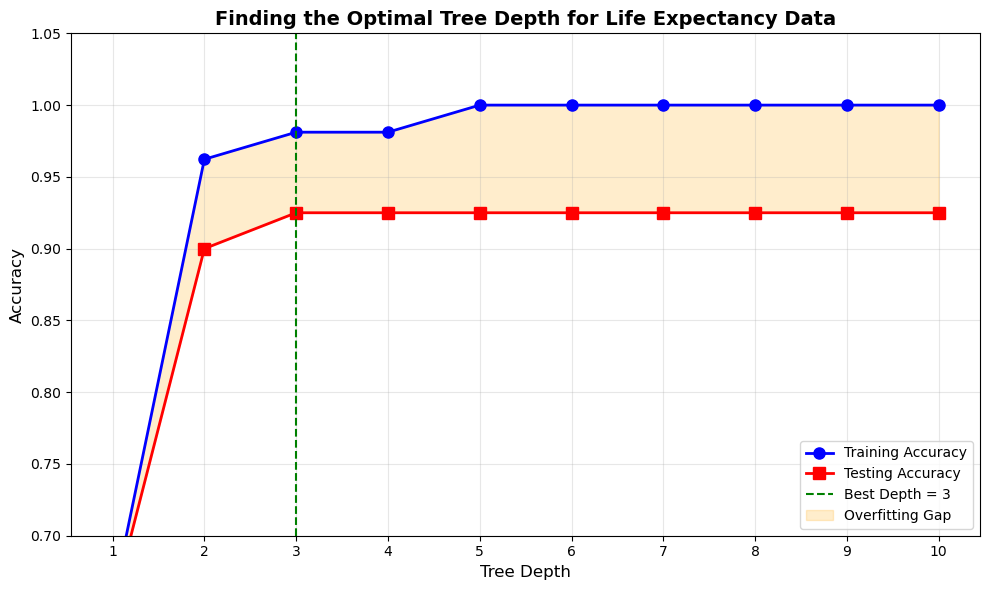


🎯 Optimal Tree Depth: 3
   Best Test Accuracy: 92.50%

💡 Observation: Notice how training accuracy keeps increasing with depth,
   but test accuracy plateaus or decreases - this is OVERFITTING!


In [8]:
# ============================================================
# CELL 8: Find Optimal Tree Depth
# ============================================================
depths = range(1, 11)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

best_depth = depths[np.argmax(test_scores)]
best_test_acc = max(test_scores)

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'b-o', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(depths, test_scores, 'r-s', label='Testing Accuracy', linewidth=2, markersize=8)
plt.axvline(x=best_depth, color='green', linestyle='--', label=f'Best Depth = {best_depth}')
plt.fill_between(depths, train_scores, test_scores, alpha=0.2, color='orange',
                 label='Overfitting Gap')

plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Finding the Optimal Tree Depth for Life Expectancy Data', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

print(f"\n🎯 Optimal Tree Depth: {best_depth}")
print(f"   Best Test Accuracy: {best_test_acc*100:.2f}%")
print("\n💡 Observation: Notice how training accuracy keeps increasing with depth,")
print("   but test accuracy plateaus or decreases - this is OVERFITTING!")

In [9]:
# ============================================================
# CELL 9: Train a Random Forest
# ============================================================
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

print("🌲 Training Random Forest with 100 trees...")
rf.fit(X_train, y_train)
print("✅ Training complete!")

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print("\n🌲 RANDOM FOREST RESULTS")
print("=" * 50)
print(f"\n📊 Forest Properties:")
print(f"   • Number of trees: {rf.n_estimators}")
print(f"   • Features used: {rf.n_features_in_}")

print(f"\n🎯 Accuracy:")
print(f"   • Training Accuracy: {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")
print(f"   • Testing Accuracy:  {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")

🌲 Training Random Forest with 100 trees...
✅ Training complete!

🌲 RANDOM FOREST RESULTS

📊 Forest Properties:
   • Number of trees: 100
   • Features used: 2

🎯 Accuracy:
   • Training Accuracy: 1.0000 (100.00%)
   • Testing Accuracy:  0.9750 (97.50%)


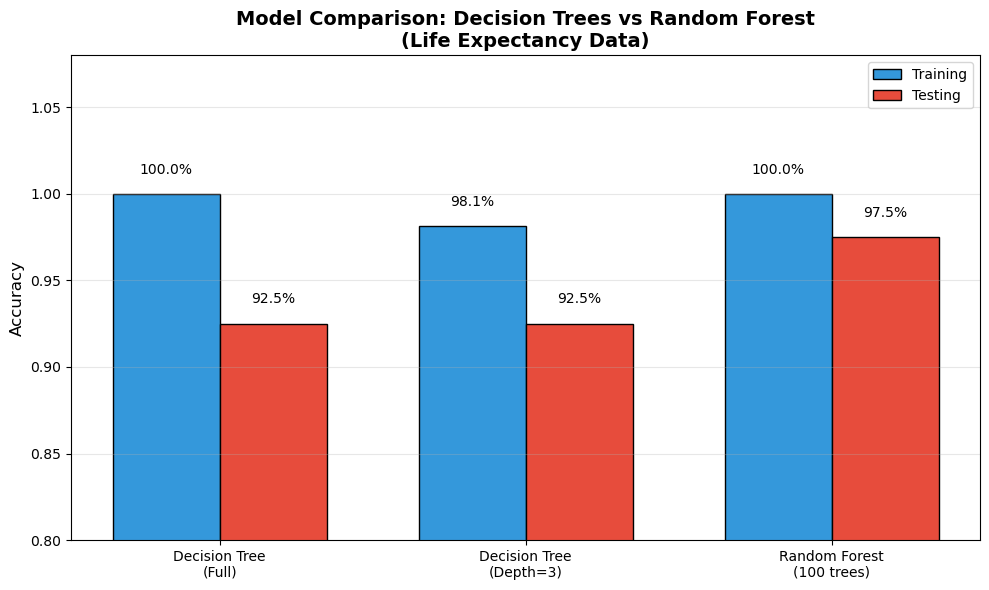


💡 Key Observations:
   • Full Decision Tree: Perfect training, may overfit
   • Simple Decision Tree: Less overfitting, but may underfit
   • Random Forest: Best of both worlds - high accuracy, good generalization!


In [10]:
# ============================================================
# CELL 10: Compare Single Tree vs Random Forest
# ============================================================
models = ['Decision Tree\n(Full)', 'Decision Tree\n(Depth=3)', 'Random Forest\n(100 trees)']
train_accs = [train_acc, train_acc_simple, train_acc_rf]
test_accs = [test_acc, test_acc_simple, test_acc_rf]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, train_accs, width, label='Training', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs, width, label='Testing', color='#e74c3c', edgecolor='black')

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height*100:.1f}%', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height*100:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison: Decision Trees vs Random Forest\n(Life Expectancy Data)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0.8, 1.08)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("   • Full Decision Tree: Perfect training, may overfit")
print("   • Simple Decision Tree: Less overfitting, but may underfit")
print("   • Random Forest: Best of both worlds - high accuracy, good generalization!")

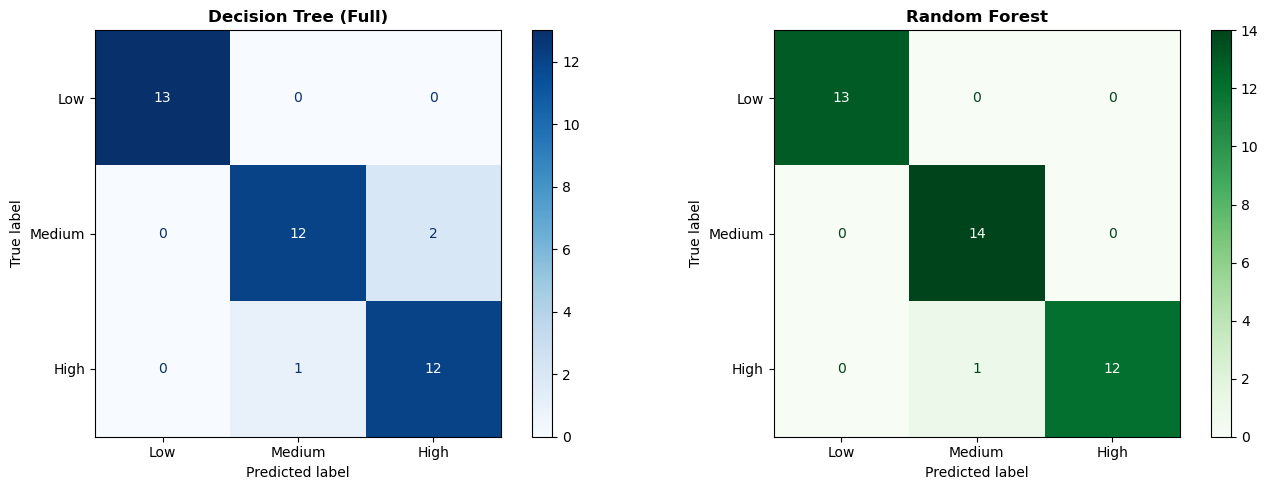


📊 RANDOM FOREST - DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        13
      Medium       0.93      1.00      0.97        14
        High       1.00      0.92      0.96        13

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.98        40
weighted avg       0.98      0.97      0.97        40



In [11]:
# ============================================================
# CELL 11: Detailed Evaluation - Random Forest
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_dt = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_dt, display_labels=['Low', 'Medium', 'High']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree (Full)', fontsize=12, fontweight='bold')

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Low', 'Medium', 'High']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 RANDOM FOREST - DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_test_pred_rf, target_names=['Low', 'Medium', 'High']))

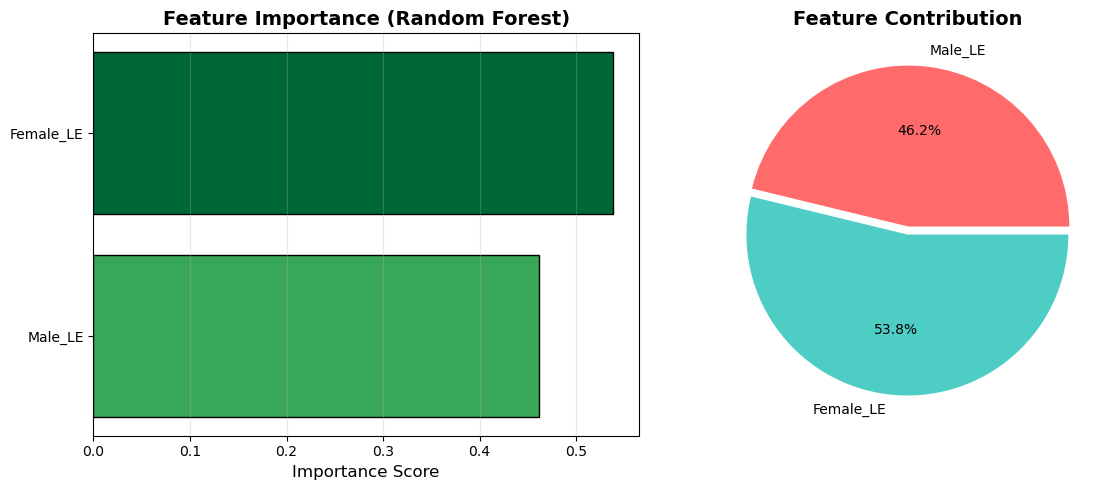


🏆 FEATURE IMPORTANCE RANKING:
   Female_LE       0.5379 ██████████████████████████
   Male_LE         0.4621 ███████████████████████

💡 Observation: Female and Male life expectancy have similar importance!
   Both genders contribute equally to predicting overall life expectancy.


In [12]:
# ============================================================
# CELL 12: Extract and Visualize Feature Importance
# ============================================================
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = plt.cm.RdYlGn(feature_importance_df['Importance'] / feature_importance_df['Importance'].max())
axes[0].barh(feature_importance_df['Feature'], feature_importance_df['Importance'], 
             color=colors, edgecolor='black')
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

axes[1].pie(feature_importance_df['Importance'], labels=feature_importance_df['Feature'], 
            autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'], explode=[0.05, 0])
axes[1].set_title('Feature Contribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🏆 FEATURE IMPORTANCE RANKING:")
print("=" * 50)
for i, row in feature_importance_df.sort_values('Importance', ascending=False).iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"   {row['Feature']:15s} {row['Importance']:.4f} {bar}")

if abs(importances[0] - importances[1]) < 0.1:
    print("\n💡 Observation: Female and Male life expectancy have similar importance!")
    print("   Both genders contribute equally to predicting overall life expectancy.")
else:
    dominant = feature_names[np.argmax(importances)]
    print(f"\n💡 Observation: {dominant} life expectancy is the dominant predictor.")

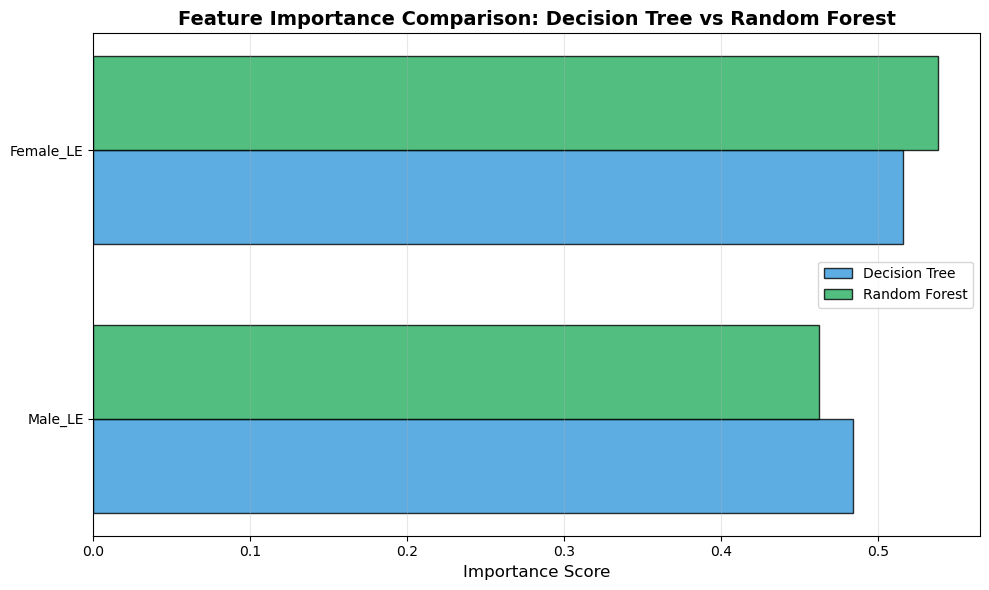


💡 Observations:
   • Decision Trees may over-rely on one feature
   • Random Forests provide more balanced importance scores
   • RF importance is more stable due to averaging across many trees


In [13]:
# ============================================================
# CELL 13: Compare Feature Importance - Decision Tree vs Random Forest
# ============================================================
dt_importances = dt_basic.feature_importances_

importance_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Decision Tree': dt_importances,
    'Random Forest': importances
})

importance_comparison = importance_comparison.sort_values('Random Forest', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(feature_names))
width = 0.35

ax.barh(y_pos - width/2, importance_comparison['Decision Tree'], width, 
        label='Decision Tree', color='#3498db', edgecolor='black', alpha=0.8)
ax.barh(y_pos + width/2, importance_comparison['Random Forest'], width, 
        label='Random Forest', color='#27ae60', edgecolor='black', alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(importance_comparison['Feature'])
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance Comparison: Decision Tree vs Random Forest', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Observations:")
print("   • Decision Trees may over-rely on one feature")
print("   • Random Forests provide more balanced importance scores")
print("   • RF importance is more stable due to averaging across many trees")

In [14]:
# ============================================================
# CELL 14: Hyperparameter Tuning with GridSearchCV
# ============================================================
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

print("🔍 Starting GridSearchCV (this may take a minute)...")
print(f"   Testing {2*3*2*2} = {2*3*2*2} parameter combinations with 5-fold CV")
print(f"   Total fits: {2*3*2*2*5} = {2*3*2*2*5}")

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n✅ GridSearchCV Complete!")
print("\n" + "="*60)
print("🏆 BEST PARAMETERS FOUND:")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")

print(f"\n🎯 Best Cross-Validation Score: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

🔍 Starting GridSearchCV (this may take a minute)...
   Testing 24 = 24 parameter combinations with 5-fold CV
   Total fits: 120 = 120
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ GridSearchCV Complete!

🏆 BEST PARAMETERS FOUND:
   • max_depth: 3
   • min_samples_leaf: 1
   • min_samples_split: 2
   • n_estimators: 100

🎯 Best Cross-Validation Score: 0.9431 (94.31%)


🏆 OPTIMIZED RANDOM FOREST RESULTS

🎯 Performance:
   • Training Accuracy: 0.9937 (99.37%)
   • Testing Accuracy:  0.9500 (95.00%)

📊 Improvement over default Random Forest:
   Test accuracy decreased by 2.50% (default was already good!)


<Figure size 800x600 with 0 Axes>

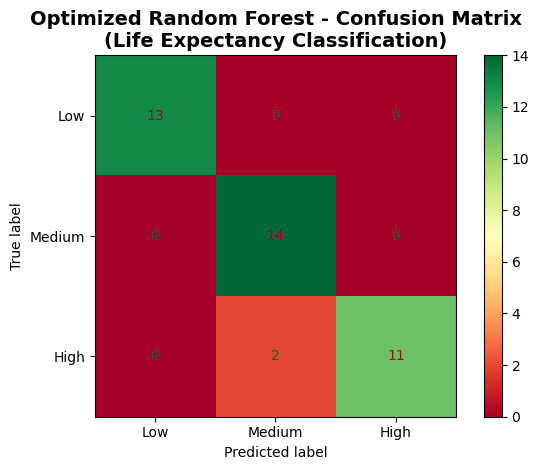


📋 Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        13
      Medium       0.88      1.00      0.93        14
        High       1.00      0.85      0.92        13

    accuracy                           0.95        40
   macro avg       0.96      0.95      0.95        40
weighted avg       0.96      0.95      0.95        40



In [15]:
# ============================================================
# CELL 15: Evaluate the Best Model
# ============================================================
best_rf = grid_search.best_estimator_

y_test_pred_best = best_rf.predict(X_test)
y_train_pred_best = best_rf.predict(X_train)

train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print("🏆 OPTIMIZED RANDOM FOREST RESULTS")
print("=" * 60)
print(f"\n🎯 Performance:")
print(f"   • Training Accuracy: {train_acc_best:.4f} ({train_acc_best*100:.2f}%)")
print(f"   • Testing Accuracy:  {test_acc_best:.4f} ({test_acc_best*100:.2f}%)")

print(f"\n📊 Improvement over default Random Forest:")
improvement = (test_acc_best - test_acc_rf) * 100
if improvement > 0:
    print(f"   Test accuracy improved by {improvement:.2f}%")
elif improvement < 0:
    print(f"   Test accuracy decreased by {abs(improvement):.2f}% (default was already good!)")
else:
    print(f"   Same performance as default")

plt.figure(figsize=(8, 6))
cm_best = confusion_matrix(y_test, y_test_pred_best)
ConfusionMatrixDisplay(cm_best, display_labels=['Low', 'Medium', 'High']).plot(cmap='RdYlGn')
plt.title('Optimized Random Forest - Confusion Matrix\n(Life Expectancy Classification)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_test, y_test_pred_best, target_names=['Low', 'Medium', 'High']))

📊 FINAL MODEL COMPARISON - LIFE EXPECTANCY DATA
                    Model Training Accuracy Testing Accuracy Overfitting Gap
     Decision Tree (Full)           100.00%           92.50%           7.50%
  Decision Tree (Depth=3)            98.11%           92.50%           5.61%
  Random Forest (Default)           100.00%           97.50%           2.50%
Random Forest (Optimized)            99.37%           95.00%           4.37%


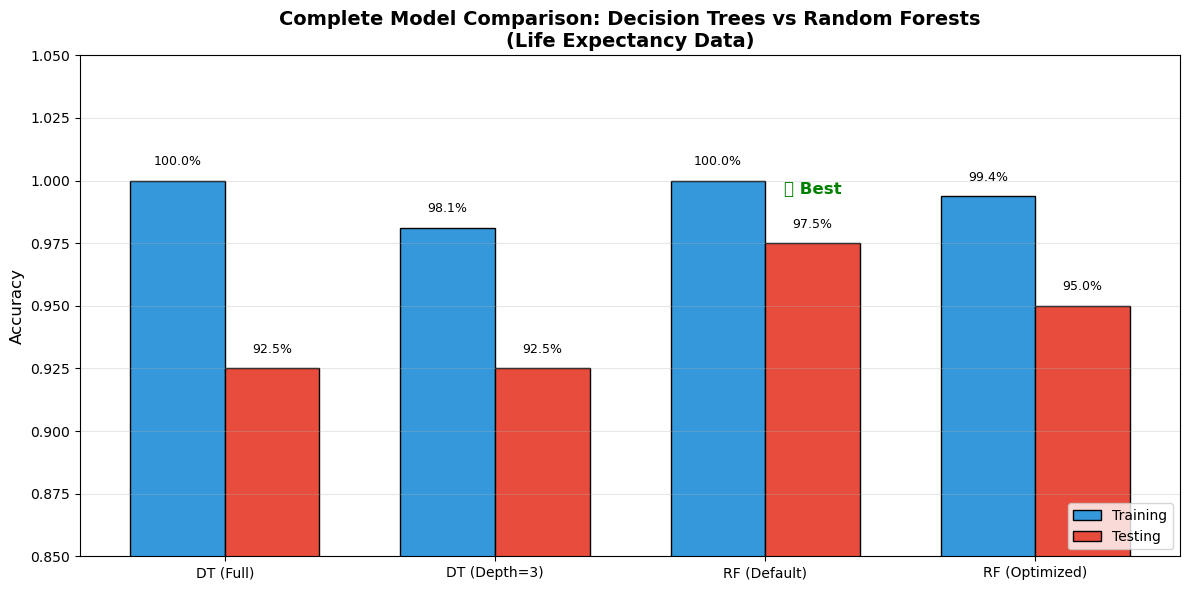

In [16]:
# ============================================================
# CELL 16: Final Model Comparison Summary
# ============================================================
summary_data = {
    'Model': ['Decision Tree (Full)', 'Decision Tree (Depth=3)', 
              'Random Forest (Default)', 'Random Forest (Optimized)'],
    'Training Accuracy': [train_acc, train_acc_simple, train_acc_rf, train_acc_best],
    'Testing Accuracy': [test_acc, test_acc_simple, test_acc_rf, test_acc_best],
    'Overfitting Gap': [train_acc - test_acc, train_acc_simple - test_acc_simple,
                        train_acc_rf - test_acc_rf, train_acc_best - test_acc_best]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Training Accuracy'] = summary_df['Training Accuracy'].apply(lambda x: f"{x*100:.2f}%")
summary_df['Testing Accuracy'] = summary_df['Testing Accuracy'].apply(lambda x: f"{x*100:.2f}%")
summary_df['Overfitting Gap'] = summary_df['Overfitting Gap'].apply(lambda x: f"{x*100:.2f}%")

print("📊 FINAL MODEL COMPARISON - LIFE EXPECTANCY DATA")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)

fig, ax = plt.subplots(figsize=(12, 6))

models = ['DT (Full)', 'DT (Depth=3)', 'RF (Default)', 'RF (Optimized)']
train_accs_all = [train_acc, train_acc_simple, train_acc_rf, train_acc_best]
test_accs_all = [test_acc, test_acc_simple, test_acc_rf, test_acc_best]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, train_accs_all, width, label='Training', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs_all, width, label='Testing', color='#e74c3c', edgecolor='black')

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{height*100:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Complete Model Comparison: Decision Trees vs Random Forests\n(Life Expectancy Data)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='lower right')
ax.set_ylim(0.85, 1.05)
ax.grid(axis='y', alpha=0.3)

best_idx = np.argmax(test_accs_all)
ax.annotate('⭐ Best', xy=(best_idx + width/2, test_accs_all[best_idx] + 0.02),
            fontsize=12, ha='center', fontweight='bold', color='green')

plt.tight_layout()
plt.show()

CROSS-VALIDATION COMPARISON (5-fold CV)

Decision Tree (Full):
   CV Scores: [0.425      0.925      1.         0.925      0.46153846]
   Mean Accuracy: 0.7473 (±0.2500)

Decision Tree (Depth=3):
   CV Scores: [0.425      0.95       1.         0.925      0.46153846]
   Mean Accuracy: 0.7523 (±0.2537)

Random Forest (Default):
   CV Scores: [0.65       0.95       1.         0.925      0.76923077]
   Mean Accuracy: 0.8588 (±0.1298)

Random Forest (Optimized):
   CV Scores: [0.65       0.95       1.         0.925      0.71794872]
   Mean Accuracy: 0.8486 (±0.1382)


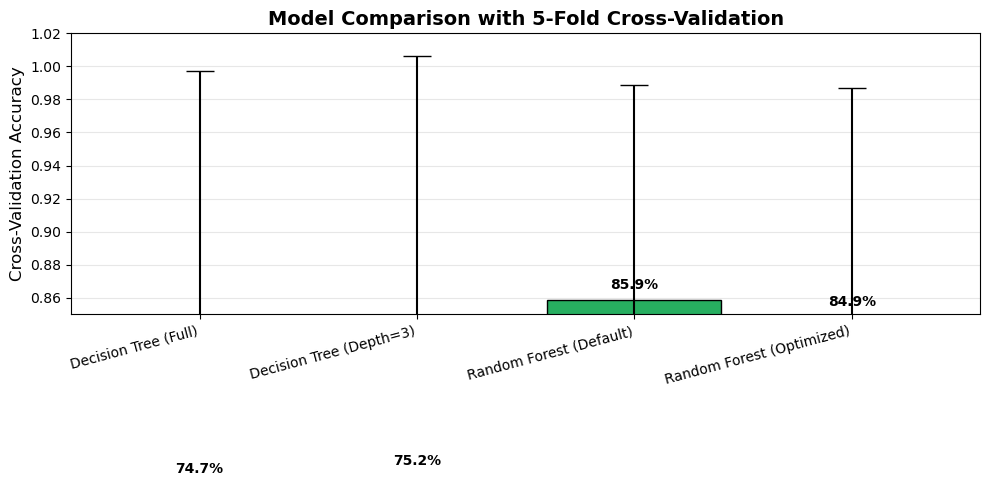


💡 Key Insight: Cross-validation gives a more reliable estimate of model performance
   than a single train-test split, especially for smaller datasets.


In [17]:
# ============================================================
# CELL 17: Cross-Validation for Robust Evaluation
# ============================================================
print("=" * 60)
print("CROSS-VALIDATION COMPARISON (5-fold CV)")
print("=" * 60)

models_cv = {
    'Decision Tree (Full)': DecisionTreeClassifier(random_state=42),
    'Decision Tree (Depth=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest (Default)': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Random Forest (Optimized)': best_rf
}

cv_results = {}
for name, model in models_cv.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_results[name] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores
    }
    print(f"\n{name}:")
    print(f"   CV Scores: {cv_scores}")
    print(f"   Mean Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

fig, ax = plt.subplots(figsize=(10, 6))
model_names = list(cv_results.keys())
means = [cv_results[m]['mean'] for m in model_names]
stds = [cv_results[m]['std'] for m in model_names]

colors = ['#3498db', '#95a5a6', '#27ae60', '#e67e22']
bars = ax.bar(range(len(model_names)), means, yerr=stds, capsize=10, color=colors, edgecolor='black')
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('Cross-Validation Accuracy', fontsize=12)
ax.set_title('Model Comparison with 5-Fold Cross-Validation', fontsize=14, fontweight='bold')
ax.set_ylim(0.85, 1.02)
ax.grid(axis='y', alpha=0.3)

for i, (bar, mean) in enumerate(zip(bars, means)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{mean*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Key Insight: Cross-validation gives a more reliable estimate of model performance")
print("   than a single train-test split, especially for smaller datasets.")

In [20]:
# ============================================================
# CELL 18: Final Summary and Key Takeaways
# ============================================================
print("=" * 80)
print("🎉 LAB COMPLETED SUCCESSFULLY! 🎉")
print("=" * 80)

print("\n📚 WHAT YOU LEARNED:")
print("-" * 50)
print("1. ✅ Decision Trees: How they make predictions through recursive splitting")
print("2. ✅ Tree Visualization: How to interpret and visualize decision paths")
print("3. ✅ Overfitting: How deep trees can memorize training data")
print("4. ✅ Random Forests: Ensemble method combining many trees")
print("5. ✅ Feature Importance: Which features matter most for predictions")
print("6. ✅ Hyperparameter Tuning: Using GridSearchCV to optimize models")
print("7. ✅ Model Evaluation: Confusion matrices, classification reports, CV")
print("8. ✅ Real-world Application: Life expectancy prediction")

print("\n🎯 KEY INSIGHTS FROM OUR DATA:")
print("-" * 50)
print(f"• Optimal Tree Depth: {best_depth}")
print(f"• Best Random Forest Test Accuracy: {test_acc_best*100:.2f}%")
print(f"• Improvement over single tree: {(test_acc_best - test_acc)*100:.2f}%")
print(f"• Most important feature: {feature_names[np.argmax(importances)]}")
print(f"• Feature balance: Female LE vs Male LE importance ratio: {max(importances)/min(importances):.2f}")

print("\n💡 PRO TIPS:")
print("-" * 50)
print("• Always visualize your trees when interpretability is important")
print("• Use Random Forests when you need high accuracy and robustness")
print("• Cross-validation gives more reliable performance estimates")
print("• Feature importance helps with feature selection and understanding")
print("• Save your best models using joblib or pickle for later use")

print("\n" + "=" * 80)
print("🌟 GREAT JOB COMPLETING THIS LAB! 🌟")
print("=" * 80)

# Display final model performance summary
print("\n📊 FINAL PERFORMANCE SUMMARY:")
comparison_data = {
    'Metric': ['Best Test Accuracy', 'Training Accuracy', 'Overfitting Gap', 'Features Used'],
    'Decision Tree (Full)': [f"{test_acc*100:.2f}%", f"{train_acc*100:.2f}%", f"{(train_acc - test_acc)*100:.2f}%", "2"],
    'Decision Tree (Depth=3)': [f"{test_acc_simple*100:.2f}%", f"{train_acc_simple*100:.2f}%", f"{(train_acc_simple - test_acc_simple)*100:.2f}%", "2"],
    'Random Forest (Optimized)': [f"{test_acc_best*100:.2f}%", f"{train_acc_best*100:.2f}%", f"{(train_acc_best - test_acc_best)*100:.2f}%", "2"]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print(f"\n🏆 WINNER: Random Forest (Optimized) with {test_acc_best*100:.2f}% test accuracy!")

🎉 LAB COMPLETED SUCCESSFULLY! 🎉

📚 WHAT YOU LEARNED:
--------------------------------------------------
1. ✅ Decision Trees: How they make predictions through recursive splitting
2. ✅ Tree Visualization: How to interpret and visualize decision paths
3. ✅ Overfitting: How deep trees can memorize training data
4. ✅ Random Forests: Ensemble method combining many trees
5. ✅ Feature Importance: Which features matter most for predictions
6. ✅ Hyperparameter Tuning: Using GridSearchCV to optimize models
7. ✅ Model Evaluation: Confusion matrices, classification reports, CV
8. ✅ Real-world Application: Life expectancy prediction

🎯 KEY INSIGHTS FROM OUR DATA:
--------------------------------------------------
• Optimal Tree Depth: 3
• Best Random Forest Test Accuracy: 95.00%
• Improvement over single tree: 2.50%
• Most important feature: Female_LE
• Feature balance: Female LE vs Male LE importance ratio: 1.16

💡 PRO TIPS:
--------------------------------------------------
• Always visualize you